In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from random import randint
import torchvision.models as models
import torch.nn as nn
from tqdm import tqdm
import umap
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import random

### ResNet-18 CIFAR-10 Feature Understanding

### Overview

#### 1. ***Dataset Preparation***
- **Transformations**: Resize images to 224x224 (ResNet input size), normalize using ImageNet statistics, and convert to tensors.
- **Dataset**: CIFAR-10 test set is loaded using `torchvision.datasets`.
- **DataLoader**: Batch processing is enabled for efficient computation.

#### 2. ***Feature Extraction***
- **Model**: Pre-trained ResNet-18 is loaded, and the final classification layer is removed to extract features.
- **Embeddings**: Features are extracted for all test images and saved as `.npy` files for further analysis.

#### 3. ***Visualization***
- **UMAP**: Dimensionality reduction using UMAP to visualize embeddings in 2D space.
- **t-SNE**: Alternative visualization using t-SNE for comparison.

#### 4. ***Nearest Neighbors***
- **Cosine Similarity**: Compute similarity between embeddings to find nearest neighbors for each class.
- **Visualization**: Display query images and their nearest neighbors.

#### 5. ***Feature Maps Exploration***
- **Hooks**: Register hooks to capture feature maps at different layers of ResNet-18.
- **Pooling**: Perform adaptive average pooling to reduce spatial dimensions.
- **PCA**: Visualize the trajectory of features across layers using PCA.

In [2]:
# Define transform
transform = transforms.Compose([
    transforms.Resize(224),  # ResNet input size
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],   # ImageNet stats
                         std=[0.229, 0.224, 0.225])
])

# Load CIFAR-10 test set
test_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

# DataLoader for batching
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

Files already downloaded and verified


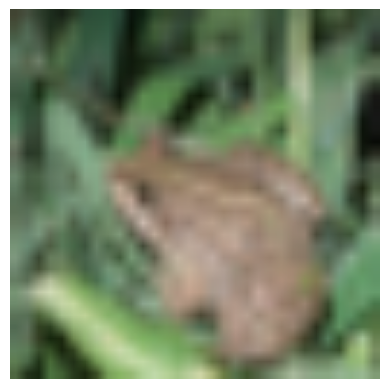

Label: frog


In [3]:
# Undo normalization for plotting
def imshow(img):
    
    img = img * torch.tensor([0.229, 0.224, 0.225]).view(3,1,1) + torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')
    plt.show()

# Visual check
images, labels = next(iter(test_loader))

random_image = randint(0, len(images) - 1)
imshow(images[random_image])

print("Label:", test_dataset.classes[labels[[random_image]]])

In [4]:
# Load pre-trained ResNet-18
resnet18 = models.resnet18(pretrained=True)

# Remove final classification layer (fc)
# We’ll use everything up to the last FC layer
model = nn.Sequential(*list(resnet18.children())[:-1])  # Exclude the classifier

# Set to evaluation mode
model.eval()

# Send to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

c:\Users\rafin\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\rafin\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [10]:
print(model)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Con

In [6]:
# Make sure model and dataloader are ready
model.eval()

all_embeddings = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_loader):
        images = images.to(device)

        # Pass through model to get features
        features = model(images)  # Output shape: [B, 512, 1, 1]
        features = features.squeeze()  # Remove [1,1] dimensions → [B, 512]

        if len(features.shape) == 1:
            features = features.unsqueeze(0)  # Handle batch size = 1

        all_embeddings.append(features.cpu())
        all_labels.append(labels)

# Stack into arrays
all_embeddings = torch.cat(all_embeddings, dim=0).numpy()  # Shape: [10000, 512]
all_labels = torch.cat(all_labels, dim=0).numpy()  # Shape: [10000]

100%|██████████| 157/157 [00:16<00:00,  9.38it/s]


In [7]:
os.makedirs("embeddings", exist_ok=True)
np.save("embeddings/resnet18_cifar10_embeddings.npy", all_embeddings)
np.save("embeddings/resnet18_cifar10_labels.npy", all_labels)

In [8]:
print(np.load("embeddings/resnet18_cifar10_embeddings.npy").shape)
print(np.load("embeddings/resnet18_cifar10_labels.npy").shape)

(10000, 512)
(10000,)


In [5]:
embeddings = np.load("embeddings/resnet18_cifar10_embeddings.npy")
labels = np.load("embeddings/resnet18_cifar10_labels.npy")

In [16]:
unique_idxs = np.unique(labels)

print("Unique label indices and names:")
for idx in unique_idxs:
    print(f"{idx}: {test_dataset.classes[idx]}")

Unique label indices and names:
0: airplane
1: automobile
2: bird
3: cat
4: deer
5: dog
6: frog
7: horse
8: ship
9: truck


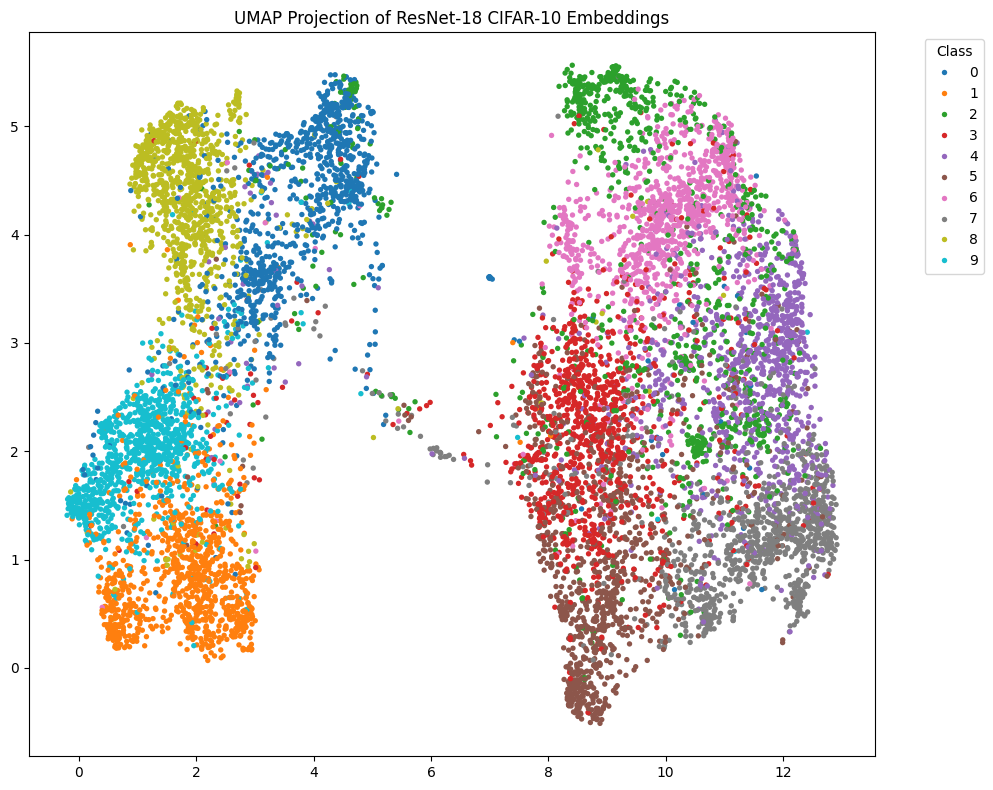

In [10]:
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='cosine')
embedding_2d = reducer.fit_transform(embeddings)  # Shape: [10000, 2]

plt.figure(figsize=(10, 8))
sns.scatterplot(x=embedding_2d[:, 0], y=embedding_2d[:, 1], hue=labels, palette='tab10', s=15, linewidth=0)
plt.title("UMAP Projection of ResNet-18 CIFAR-10 Embeddings")
plt.legend(title='Class', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

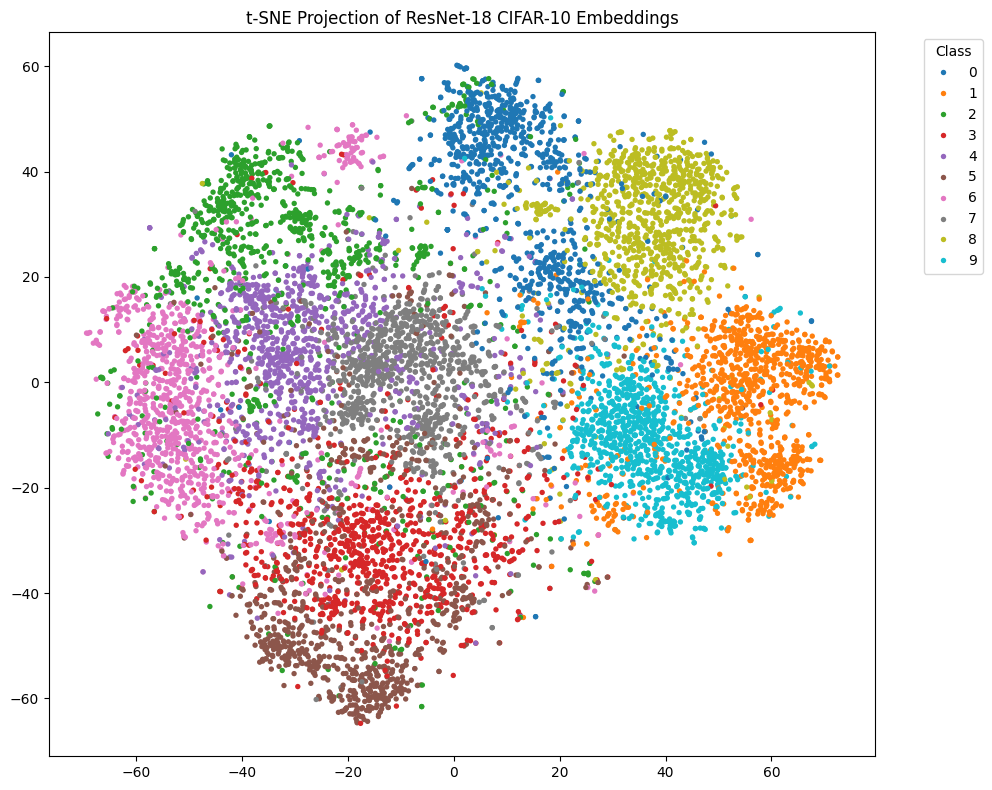

In [11]:
tsne = TSNE(n_components=2, perplexity=30, metric='cosine', n_iter=1000)
tsne_2d = tsne.fit_transform(embeddings)

plt.figure(figsize=(10, 8))
sns.scatterplot(x=tsne_2d[:, 0], y=tsne_2d[:, 1], hue=labels, palette='tab10', s=15, linewidth=0)
plt.title("t-SNE Projection of ResNet-18 CIFAR-10 Embeddings")
plt.legend(title='Class', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [6]:
# Map each class label to list of indices
label_to_indices = defaultdict(list)
for idx, label in enumerate(labels):
    label_to_indices[label].append(idx)

# Randomly pick one index per class (for top 10 classes)
class_to_idx = {}
top_k = 10
selected_labels = list(label_to_indices.keys())[:top_k]  # You can shuffle this if needed

for label in selected_labels:
    class_to_idx[label] = random.choice(label_to_indices[label])


top_k = 10
results = {}

for class_label, query_idx in class_to_idx.items():
    query_embedding = embeddings[query_idx].reshape(1, -1)

    # Compute cosine similarity to all embeddings
    similarities = cosine_similarity(query_embedding, embeddings)[0]  # shape: [10000]

    # Get top K most similar indices (excluding the query itself)
    similar_indices = similarities.argsort()[::-1][1:top_k+1]

    results[class_label] = {
        "query_idx": query_idx,
        "neighbors": similar_indices
    }
    
    
def unnormalize(img_tensor):
    """
    Undo normalization to convert image tensor to [0,1] range for imshow
    """
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img_tensor = img_tensor.cpu() * std + mean
    img_tensor = torch.clamp(img_tensor, 0, 1)
    return img_tensor


def show_neighbors(dataset, query_idx, neighbor_indices, class_name):
    plt.figure(figsize=(12, 2))

    # Query image
    plt.subplot(1, top_k + 1, 1)
    query_img = unnormalize(dataset[query_idx][0])
    plt.imshow(query_img.permute(1, 2, 0).numpy())
    plt.title(f"Query\nClass: {class_name}")
    plt.axis('off')

    # Neighbors
    for i, idx in enumerate(neighbor_indices):
        plt.subplot(1, top_k + 1, i + 2)
        nn_img = unnormalize(dataset[idx][0])
        plt.imshow(nn_img.permute(1, 2, 0).numpy())

        # Get the actual label name from dataset.labels or dataset.targets
        nn_label_idx = dataset[idx][1]  # This is the label index
        nn_label_name = dataset.classes[nn_label_idx]

        plt.title(f"NN {i+1}\n{nn_label_name}", fontsize=8)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

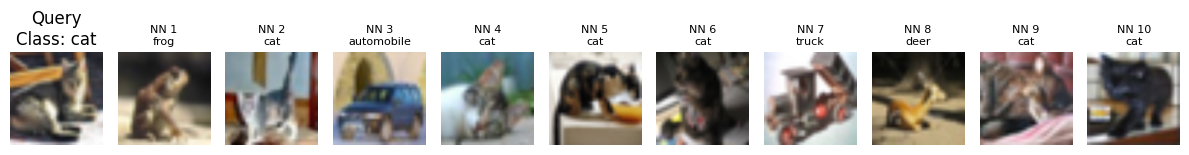

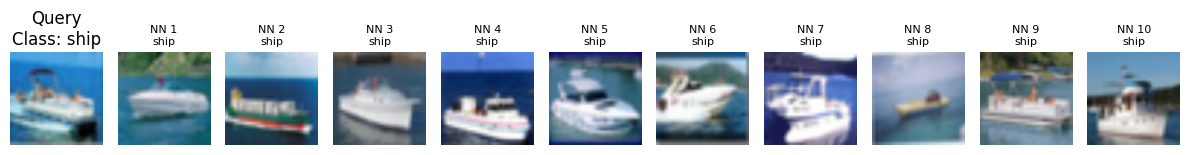

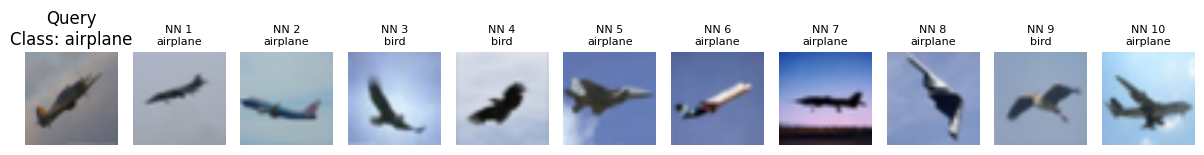

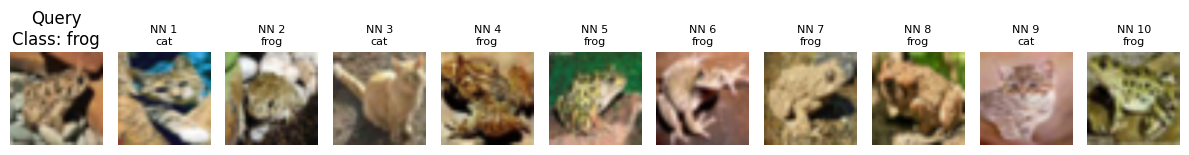

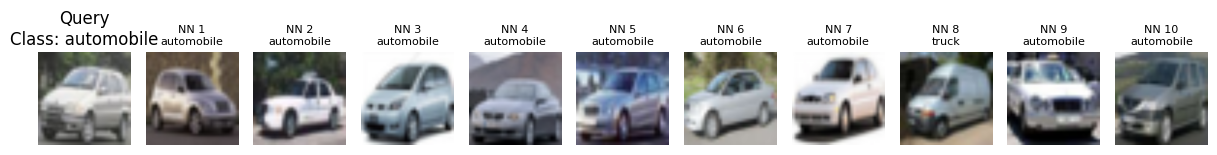

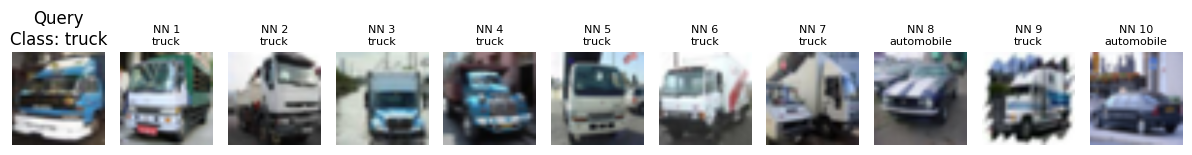

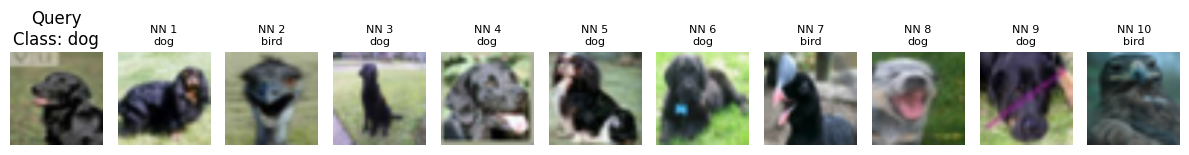

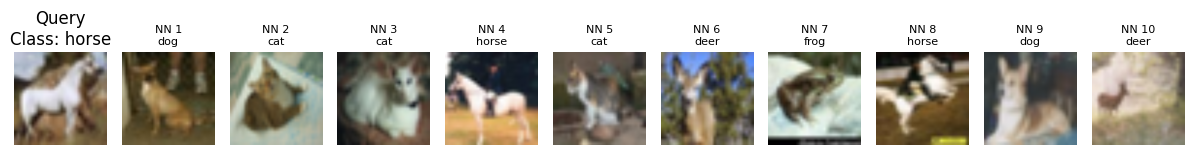

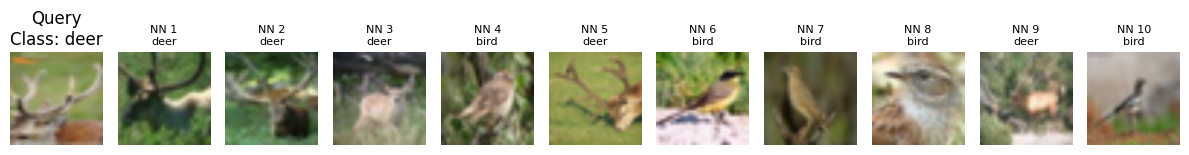

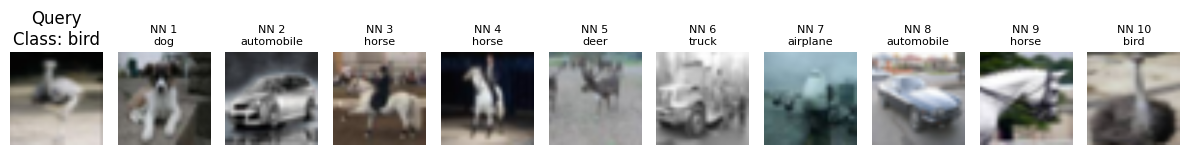

In [18]:
for class_label, data in results.items():
    show_neighbors(
        dataset=test_dataset,
        query_idx=data["query_idx"],
        neighbor_indices=data["neighbors"],
        class_name=test_dataset.classes[class_label]
    )

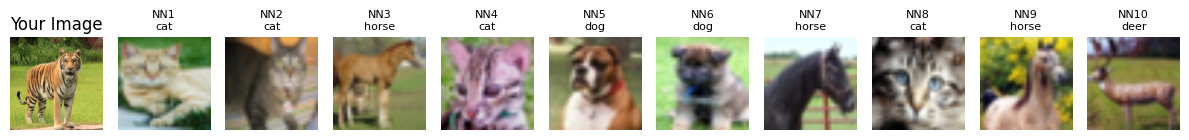

In [7]:
from PIL import Image

# Parameters
your_image_path = "tiger.jpg"  
top_k = 10

# 1. Load and preprocess your image
img = Image.open(your_image_path).convert("RGB")
img_t = transform(img).unsqueeze(0).to(device)  # reuse `transform` and `device` from above

# 2. Extract its embedding
model.eval()
with torch.no_grad():
    feat = model(img_t)         # [1, 512, 1, 1]
    feat = feat.squeeze().cpu().numpy().reshape(1, -1)

# 3. Compute cosine similarities to all saved embeddings
all_emb = embeddings          # loaded earlier: np.load("embeddings/...npy")
sims = cosine_similarity(feat, all_emb)[0]

# 4. Get top_k neighbor indices (skip the image itself if accidentally included)
neighbor_idxs = sims.argsort()[::-1][:top_k]

# 5. Display query + neighbors
plt.figure(figsize=(12, 2))

# Query
plt.subplot(1, top_k+1, 1)
plt.imshow(img.resize((224,224)))
plt.title("Your Image")
plt.axis("off")

# Neighbors
for i, idx in enumerate(neighbor_idxs):
    ds_img, ds_lbl = test_dataset[idx]
    nn_img = unnormalize(ds_img)  # reuse unnormalize function
    plt.subplot(1, top_k+1, i+2)
    plt.imshow(nn_img.permute(1,2,0).numpy())
    plt.title(f"NN{i+1}\n{test_dataset.classes[ds_lbl]}", fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()
